# Solving the default layout instance with `pyomo-cp`

This example comes from a deployed Streamlit plant-layout application, [plant-layout.griffith-pse.com](https://plant-layout.griffith-pse.com/) (part of [griffith-pse.com](https://griffith-pse.com)). The app builds a **`pyomo.gdp`** model (a 4-way non-overlap
disjunction per pair of blocks) and normally solves it by reformulating the
disjunctions to a MILP (big-M) and calling **Gurobi**.

This notebook takes the same `pyomo.gdp` model and solves it with
**CP-SAT** (Google OR-Tools) instead, through the
[`pyomo-cp`](https://github.com/devin-griff/pyomo-cp) package. The disjunctions
map to native reified CP constraints rather than being reformulated, and the
continuous coordinates are placed on a half-unit grid chosen to capture this
instance exactly. The result is the same optimum the app's MILP path finds:
**255.5**.

> Install once: `pip install "pyomo-cp[cpsat]"` (pulls in Pyomo and OR-Tools).

In [1]:
# !pip install "pyomo-cp[cpsat]"
import random
import time

import pyomo.environ as pyo
from pyomo.gdp import Disjunction

import pyomo_cp  # registers the 'cp.discretize' transform and the 'cpsat' solver

## 1. The default instance

The app's default instance is `seed = 1` with 15 objects: a fixed 9x1 pipe
**rack** (object 1) plus 14 small units, each with a length, width, unit pipe
cost, and a north/south rack end it ties into. Two zero-length **tie-in
headers** are appended (indices 16 and 17) as virtual pipe targets pinned to
the rack's ends.

On top of the rack tie-ins, the instance carries direct **unit-to-unit
connections** (close-coupled pairs): a disjoint pairing of the units is rolled
once from an independent seed, and the first 3 pairs are active at pipe cost
10 per unit distance (the app's "Connections" and "Cost x" defaults). This is
exactly the `_gen_objects` / `_gen_pairs` / `_objs_to_inputs` logic from
`app.py`.

In [2]:
RACK_LEN, RACK_WID = 9, 1
DEFAULT_SEED, DEFAULT_N = 1, 15
DEFAULT_PAIRS, PAIR_WEIGHT = 3, 10


def gen_objects(seed, objs):
    """Roll dims/costs/side for non-rack objects; rack stays fixed. Same RNG
    sequence as the app."""
    rng = random.Random(seed)
    objs = list(objs)
    rack = objs[0]
    length, width, cost = {rack: RACK_LEN}, {rack: RACK_WID}, {rack: 0}
    for oid in objs[1:]:
        length[oid] = rng.randint(1, 3)
        width[oid] = rng.randint(1, 3)
        cost[oid] = rng.randint(1, 3)
    side = {oid: rng.choice(["N", "S"]) for oid in objs[1:]}
    return objs, length, width, cost, side


def gen_pairs(seed, objs):
    """Roll a full disjoint pairing of the non-rack objects, seeded
    independently of the dims/costs draw. The app activates the first
    DEFAULT_PAIRS of them at pipe cost PAIR_WEIGHT."""
    rng = random.Random(seed + 10_000_019)
    units = list(objs[1:])
    rng.shuffle(units)
    return [(units[k], units[k + 1]) for k in range(0, len(units) - 1, 2)]


def objs_to_inputs(objs, length, width, cost, side, pairs):
    """Map the object list onto build_model's (n, l0, w0, cmat), appending the
    two zero-length N/S headers and adding the active pair costs."""
    nu = len(objs)
    north, south = nu + 1, nu + 2
    n = nu + 2
    l0 = {p: int(length[objs[p - 1]]) for p in range(1, nu + 1)}
    w0 = {p: int(width[objs[p - 1]]) for p in range(1, nu + 1)}
    l0[north] = l0[south] = 0
    w0[north] = w0[south] = RACK_WID
    cmat = [[0.0] * n for _ in range(n)]
    for p in range(2, nu + 1):
        h = north if side[objs[p - 1]] == "N" else south
        cmat[h - 1][p - 1] = float(cost[objs[p - 1]])
    pos = {oid: k + 1 for k, oid in enumerate(objs)}
    for a, b in pairs:
        pa, pb = pos[a], pos[b]
        cmat[max(pa, pb) - 1][min(pa, pb) - 1] += float(PAIR_WEIGHT)
    return n, l0, w0, cmat


objs, length, width, cost, side = gen_objects(DEFAULT_SEED, list(range(1, DEFAULT_N + 1)))
pairs = gen_pairs(DEFAULT_SEED, objs)[:DEFAULT_PAIRS]
n, l0, w0, cmat = objs_to_inputs(objs, length, width, cost, side, pairs)

print(f"{n} blocks (rack + {DEFAULT_N - 1} units + 2 headers)\n")
print(" obj   L   W  cost  side")
for o in objs:
    print(f"{o:>4}  {length[o]:>2}  {width[o]:>2}  {cost[o]:>4}   {side.get(o, '-')}")
print("\nactive unit-to-unit pairs (cost 10 each):", pairs)

17 blocks (rack + 14 units + 2 headers)

 obj   L   W  cost  side
   1   9   1     0   -
   2   1   3     1   N
   3   2   1     2   S
   4   2   2     3   N
   5   2   1     1   N
   6   2   1     2   S
   7   2   3     1   S
   8   3   2     2   N
   9   3   1     3   S
  10   1   2     1   N
  11   1   1     3   N
  12   3   1     2   S
  13   3   1     2   N
  14   3   1     3   S
  15   1   2     2   S

active unit-to-unit pairs (cost 10 each): [(4, 3), (2, 14), (13, 10)]


## 2. The GDP model

This is the app's `build_model` with its default settings: fixed orientation
(`rotate=False`), horizontal symmetry break (`sym=1`), minimum separation
`d = 1`. Distances are **center-to-center rectilinear** (the process-plant
layout literature convention), defined globally so the disjunction decides
only non-overlap. The objective minimizes the plant bounding box plus
cost-weighted piping: each unit to its assigned rack header, plus the direct
unit-to-unit connections.

Two deliberate deviations from `app.py`, both CP-related:

- `l_f` / `w_f` get finite upper bounds. CP-SAT needs finite bounds; the app
  leaves them unbounded, which is fine for MILP. `UB` bounds them without
  changing the optimum.
- The app adds a degeneracy-breaking cut to the left/right disjuncts so that
  Gurobi's solution pool returns distinct physical layouts rather than
  duplicate encodings of one layout. It is omitted here: pyomo-cp does not
  use a solution pool, so the cut buys nothing.

In [3]:
FOOTPRINT_WEIGHT = 1.0
D_DEFAULT = 1


def build_model(n, l0, w0, cmat, d_uniform=D_DEFAULT, sym=1):
    m = pyo.ConcreteModel()
    m.n = pyo.Set(ordered=True, initialize=pyo.RangeSet(1, n))
    m.p = pyo.Set(initialize=m.n * m.n, dimen=2, filter=lambda m, i, j: i > j)

    m.w0 = pyo.Param(m.n, initialize=w0)
    m.l0 = pyo.Param(m.n, initialize=l0)

    c_dict = {(i, j): float(cmat[i - 1][j - 1]) for i, j in m.p}
    d_dict = {(i, j): float(d_uniform) for i, j in m.p}
    # Headers (zero-length) impose no separation.
    _hdr = {i for i in m.n if l0[i] == 0}
    for (i, j) in d_dict:
        if i in _hdr or j in _hdr:
            d_dict[(i, j)] = 0.0
    m.c = pyo.Param(m.p, initialize=c_dict)
    m.d = pyo.Param(m.p, initialize=d_dict)

    m.UB = pyo.Param(initialize=sum(max(m.l0[i], m.w0[i]) for i in m.n))

    m.x = pyo.Var(m.n, bounds=(0, m.UB))
    m.y = pyo.Var(m.n, bounds=(0, m.UB))
    m.l = pyo.Var(m.n, bounds=(0, m.UB))
    m.w = pyo.Var(m.n, bounds=(0, m.UB))
    m.dx = pyo.Var(m.p, bounds=(0, m.UB))
    m.dy = pyo.Var(m.p, bounds=(0, m.UB))
    # CP-SAT needs finite bounds; the app leaves these unbounded (fine for MILP).
    # UB bounds them without changing the optimum.
    m.l_f = pyo.Var(bounds=(0, m.UB))
    m.w_f = pyo.Var(bounds=(0, m.UB))

    @m.Constraint(m.n)
    def plant_length(m, i):
        return m.l_f >= m.y[i] + m.l[i]

    @m.Constraint(m.n)
    def plant_width(m, i):
        return m.w_f >= m.x[i] + m.w[i]

    m.rack_at_origin = pyo.Constraint(expr=m.y[1] == 0)
    m.plant_len_eq_rack = pyo.Constraint(expr=m.l_f == m.l[1])

    _headers = sorted(i for i in m.n if l0[i] == 0)
    if len(_headers) >= 1:
        hn = _headers[0]
        m.pin_north_x = pyo.Constraint(expr=m.x[hn] == m.x[1])
        m.pin_north_y = pyo.Constraint(expr=m.y[hn] == m.l_f)
    if len(_headers) >= 2:
        hs = _headers[1]
        m.pin_south_x = pyo.Constraint(expr=m.x[hs] == m.x[1])
        m.pin_south_y = pyo.Constraint(expr=m.y[hs] == 0)

    # Center-to-center rectilinear distances, defined globally (outside the
    # disjunction) so the objective is independent of the chosen relation.
    @m.Constraint(m.p)
    def dx_lb_a(m, i, j):
        return m.dx[i, j] >= (m.x[i] + m.w[i] / 2) - (m.x[j] + m.w[j] / 2)

    @m.Constraint(m.p)
    def dx_lb_b(m, i, j):
        return m.dx[i, j] >= (m.x[j] + m.w[j] / 2) - (m.x[i] + m.w[i] / 2)

    @m.Constraint(m.p)
    def dy_lb_a(m, i, j):
        return m.dy[i, j] >= (m.y[i] + m.l[i] / 2) - (m.y[j] + m.l[j] / 2)

    @m.Constraint(m.p)
    def dy_lb_b(m, i, j):
        return m.dy[i, j] >= (m.y[j] + m.l[j] / 2) - (m.y[i] + m.l[i] / 2)

    if sym == 1:
        @m.Constraint()
        def sym_1(m):
            return m.x[1] + m.w[1] / 2 <= m.x[2] + m.w[2] / 2

    m.obj = pyo.Objective(
        expr=FOOTPRINT_WEIGHT * (m.l_f + m.w_f)
        + sum(m.c[i, j] * (m.dx[i, j] + m.dy[i, j]) for i, j in m.p),
        sense=pyo.minimize,
    )

    # Non-overlap GDP: 4-way disjunction per pair, one spatial relation each.
    # (No degeneracy cut: see the note above.)
    @m.Disjunction(m.p)
    def no_overlap(m, i, j):
        return [
            [m.x[i] + m.w[i] + m.d[i, j] <= m.x[j]],   # i left of j
            [m.x[j] + m.w[j] + m.d[i, j] <= m.x[i]],   # i right of j
            [m.y[i] + m.l[i] + m.d[i, j] <= m.y[j]],   # i below j
            [m.y[j] + m.l[j] + m.d[i, j] <= m.y[i]],   # i above j
        ]

    # Fixed orientation (rotate=False): length/width pinned to defaults.
    @m.Constraint(m.n)
    def fix_l(m, i):
        return m.l[i] == m.l0[i]

    @m.Constraint(m.n)
    def fix_w(m, i):
        return m.w[i] == m.w0[i]

    return m


model = build_model(n, l0, w0, cmat)
print("model built:", n, "blocks,", len(model.p), "pairwise disjunctions")

model built: 17 blocks, 136 pairwise disjunctions


## 3. Solve with `pyomo-cp` (CP-SAT)

Two steps: discretize the continuous coordinates onto a grid
(`cp.discretize`), then solve with the `cpsat` backend. Discretization is an
explicit modelling choice, never automatic.

The step size matters here. Block dimensions are 1 to 3, so with odd
dimensions the center-to-center objective can be optimal with a block at a
half-integer coordinate, and the unit grid would miss that. A **half-unit
grid** (`step = 1/2`) contains those points: on this instance it recovers the
app's continuous optimum exactly.

CP-SAT proves the optimum in about a minute on a laptop.

In [4]:
pyo.TransformationFactory("cp.discretize").apply_to(model, step=1 / 2)  # explicit; half-unit grid

t0 = time.perf_counter()
res = pyo.SolverFactory("cpsat").solve(model, workers=8, seed=42, time_limit=600, tee=True)
wall = time.perf_counter() - t0

print("termination:", res.solver.termination_condition)
print("objective  :", pyo.value(model.obj))
print(f"wall time  : {wall:.1f} s")

Starting CP-SAT solver v9.15.6755


Parameters: random_seed: 42 max_time_in_seconds: 600 log_search_progress: true num_search_workers: 8 log_to_stdout: false


Initial optimization model '': (model_fingerprint: 0x38cb5245900ce0fc)
#Variables: 886 (#ints: 36 in objective) (709 primary variables)
  - 544 Booleans in [0,1]
  - 342 in [0,90]
#kExactlyOne: 136 (#literals: 544)
#kLinear1: 36
#kLinear2: 4
#kLinear3: 578 (#enforced: 544)
#kLinearN: 545 (#terms: 2'724)


Starting presolve at 0.01s


  1.83e-04s  0.00e+00d  [DetectDominanceRelations] 


...

Improving bounds shared    Num  Sym
                  'core':   55    0
            'default_lp':   10    0
                 'no_lp':    4    0
         'quick_restart':   78    0
         'reduced_costs':  260    0



Clauses shared        #Exported  #Imported  #BinaryRead  #BinaryTotal
             'core':         55      2'006           96            96
       'default_lp':        273      1'789           96            96
  'fs_random_no_lp':          0          0            0            96
           'max_lp':         77      2'002           96            96
            'no_lp':        417      1'692           96            96
    'quick_restart':      1'420        762           96            96
    'reduced_costs':         59      2'039           96            96



LRAT_status: NA


CpSolverResponse summary:
status: OPTIMAL
objective: 511
best_bound: 511
integers: 50
booleans: 377
conflicts: 0
branches: 0
propagations: 0
integer_propagations: 0
restarts: 0
lp_iterations: 0
walltime: 126.532
usertime: 126.532
deterministic_time: 228.131
gap_integral: 77.3704
solution_fingerprint: 0x48fb2dc6a2bb1e97



termination: optimal
objective  : 255.5
wall time  : 127.2 s


## 4. The layout

Read the block placements back off the Pyomo variables (`pyomo-cp` loads the
CP-SAT solution onto them) and draw the layout the way the app renders it:
colored blocks with the rack in white, the dashed plant bounding box, each
unit's rack tie-in threaded through its own lane inside the rack, and the
unit-to-unit connections drawn as elbows dashed in their two endpoint
colors. Pipe linewidth scales with the pipe cost.

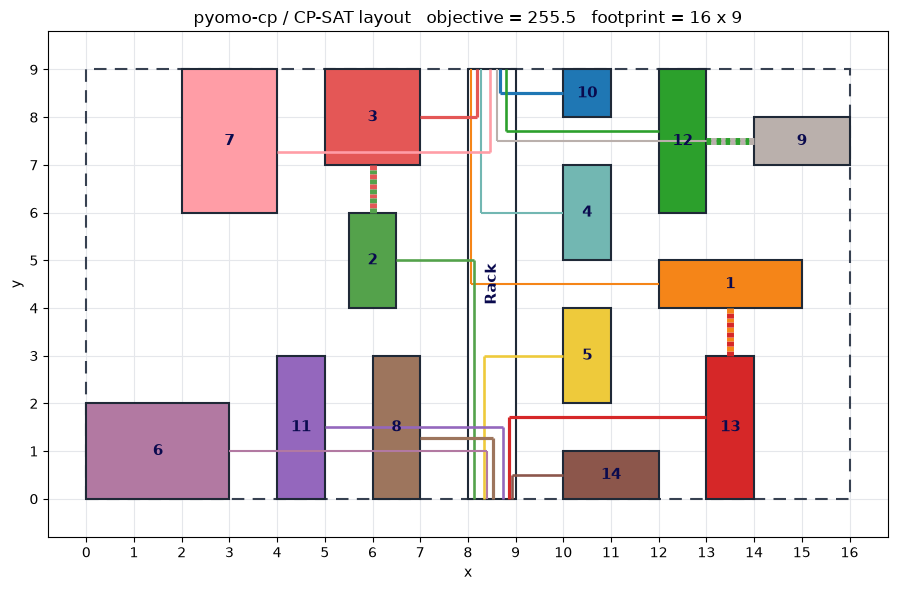

In [5]:
import math

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# The app's palette: each object's index drives its block fill, and each
# pipe takes its object's color.
PALETTE = [
    "#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#EECA3B",
    "#B279A2", "#FF9DA6", "#9D755D", "#BAB0AC", "#1F77B4", "#9467BD",
    "#2CA02C", "#D62728", "#8C564B", "#E377C2", "#17BECF", "#BCBD22",
    "#AEC7E8", "#FFBB78", "#98DF8A", "#C5B0D5", "#C49C94", "#7F7F7F",
    "#DBDB8D",
]

val = pyo.value
blocks = {i: {"x": val(model.x[i]), "y": val(model.y[i]),
              "w": val(model.w[i]), "l": val(model.l[i])} for i in model.n}
headers = {i for i in model.n if l0[i] == 0}
l_f, w_f = val(model.l_f), val(model.w_f)
color = {i: "#ffffff" if i == 1 else PALETTE[(i - 1) % len(PALETTE)]
         for i in model.n}

# Every pair with a pipe: (i, j) has i > j, so tie-in pairs lead with the
# header. Linewidth scales with pipe cost, matching the app's 1.5-5 px range.
pipes = [(i, j, val(model.c[i, j])) for (i, j) in model.p
         if val(model.c[i, j]) > 0]
c_lo, c_hi = (min(c for *_, c in pipes), max(c for *_, c in pipes))


def lw(c):
    return 2.5 if c_hi == c_lo else 1.5 + 3.5 * (c - c_lo) / (c_hi - c_lo)


def elbow(bi, bj):
    """The app's stylized face-to-face elbow between two blocks: leave block
    i at the midline of the face toward block j, run to block j's center
    coordinate, enter j through the middle of a face. One or two segments."""
    xi, yi, wi, li = bi["x"], bi["y"], bi["w"], bi["l"]
    xj, yj, wj, lj = bj["x"], bj["y"], bj["w"], bj["l"]
    cx_i, cy_i = xi + wi / 2, yi + li / 2
    cx_j, cy_j = xj + wj / 2, yj + lj / 2
    if (xi + wi <= xj) or (xj + wj <= xi):        # disjoint in x
        src_x = xi + wi if cx_j > cx_i else xi
        if yj <= cy_i <= yj + lj:
            dst_x = xj if cx_j > cx_i else xj + wj
            return [(src_x, cy_i, dst_x, cy_i)]
        dst_y = yj if cy_i < yj else yj + lj
        return [(src_x, cy_i, cx_j, cy_i), (cx_j, cy_i, cx_j, dst_y)]
    src_y = yi + li if cy_j > cy_i else yi        # disjoint in y
    if xj <= cx_i <= xj + wj:
        dst_y = yj if cy_j > cy_i else yj + lj
        return [(cx_i, src_y, cx_i, dst_y)]
    dst_x = xj if cx_i < xj else xj + wj
    return [(cx_i, src_y, cx_i, cy_j), (cx_i, cy_j, dst_x, cy_j)]


fig, ax = plt.subplots(figsize=(10, 6))

# Plant bounding box (dashed), then the blocks. Headers are virtual pipe
# targets, not physical equipment: they are not drawn.
ax.add_patch(Rectangle((0, 0), w_f, l_f, fill=False, edgecolor="#374151",
                       lw=1.5, ls=(0, (6, 4)), zorder=1))
for i, b in blocks.items():
    if i in headers:
        continue
    ax.add_patch(Rectangle((b["x"], b["y"]), b["w"], b["l"],
                           facecolor=color[i], edgecolor="#1f2937",
                           lw=1.5, zorder=2))

# Rack tie-ins: a horizontal feeder from the unit's rack-facing edge to its
# own lane inside the rack, then a vertical run along the lane to the
# assigned end (north = l_f, south = 0). Lanes fan the runs across the
# rack's width; feeders sharing a height stagger into a small band.
rack = blocks[1]
rx, rw = rack["x"], rack["w"]
tie_ins = sorted(j for i, j, c in pipes if i in headers)
lane_x = {o: rx + rw * (k + 1) / (len(tie_ins) + 1)
          for k, o in enumerate(tie_ins)}
groups = {}
for o in tie_ins:
    b = blocks[o]
    groups.setdefault(round(b["y"] + b["l"] / 2, 2), []).append(o)
feeder_y = {}
for yc, members in groups.items():
    members.sort(key=lambda o: lane_x[o])
    for k, o in enumerate(members):
        b = blocks[o]
        y = yc + (k - (len(members) - 1) / 2) * 0.22
        feeder_y[o] = min(max(y, b["y"] + 0.05), b["y"] + b["l"] - 0.05)

for h, o, c in ((i, j, c) for i, j, c in pipes if i in headers):
    b = blocks[o]
    y_c = feeder_y[o]
    edge_x = b["x"] if b["x"] >= rx + rw else b["x"] + b["w"]
    ax.plot([edge_x, lane_x[o]], [y_c, y_c], color=color[o], lw=lw(c),
            solid_capstyle="butt", zorder=3)
    ax.plot([lane_x[o]] * 2, [y_c, blocks[h]["y"]], color=color[o], lw=lw(c),
            solid_capstyle="butt", zorder=3)

# Unit-to-unit pipes: elbow path in short dashes alternating the two
# endpoint colors, so the connection reads as belonging to both ends.
DASH = 0.1
for i, j, c in pipes:
    if i in headers:
        continue
    k = 0
    for x1, y1, x2, y2 in elbow(blocks[i], blocks[j]):
        n_dash = max(1, math.ceil((abs(x2 - x1) + abs(y2 - y1)) / DASH))
        for s in range(n_dash):
            t0, t1 = s / n_dash, (s + 1) / n_dash
            ax.plot([x1 + t0 * (x2 - x1), x1 + t1 * (x2 - x1)],
                    [y1 + t0 * (y2 - y1), y1 + t1 * (y2 - y1)],
                    color=color[i] if k % 2 == 0 else color[j], lw=lw(c),
                    solid_capstyle="butt", zorder=3)
            k += 1

# Labels on top: the rack's reads along its tall, thin bar.
for i, b in blocks.items():
    if i in headers:
        continue
    ax.text(b["x"] + b["w"] / 2, b["y"] + b["l"] / 2,
            "Rack" if i == 1 else str(i - 1),
            ha="center", va="center", fontsize=11, fontweight="bold",
            color="#0a0a4e", rotation=90 if i == 1 else 0, zorder=4)

pad = 0.05 * max(l_f, w_f, 1.0)
ax.set_xlim(-pad, w_f + pad)
ax.set_ylim(-pad, l_f + pad)
ax.set_aspect("equal", adjustable="box")
ax.set_xticks(range(int(w_f) + 1))
ax.set_yticks(range(int(l_f) + 1))
ax.grid(True, color="#e5e7eb", lw=0.8)
ax.set_axisbelow(True)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"pyomo-cp / CP-SAT layout   "
             f"objective = {val(model.obj):g}   "
             f"footprint = {w_f:g} x {l_f:g}")
plt.tight_layout()
plt.show()

The same `pyomo.gdp` model the app reformulates to a MILP for Gurobi is solved
here by CP-SAT through `pyomo-cp` and returns the same optimum (**255.5**).
The only CP-specific steps are the explicit `cp.discretize` call (half-unit
grid, exact for this instance) and finite bounds on the two plant-extent
variables; the model is otherwise identical.